# Exploratory Data analysis
*The real work of an expedition begins when you return.--Louise Arner Boyd*

## Exploratory vs Confirmatory data analysis 
Exploratory data analysis (**EDA**) is the study of: the potential for data to answer hypotheses and how to generate novel hypotheses by the study of relationships between collected information.
This is in contrast to confirmatory data analysis. 
Confirmatory data analysis techniques are hypothesis tests, confidence intervals, statistical estimators---methods by which we seek to understand all possible experiments by observing a smaller number of experiments. 

Both analyses are important. We will start with EDA. 

## Descriptive Statistics 

The goal of descriptive statistics are to characterize a larger set of observations with a smaller set of numbers.

Consider storing the each observation from a set of experiments as a component of a vector.
\begin{align}
    v = [ v_{1},v_{2},\cdots,v_{N}]^{T}
\end{align}

Its easiest to think of a vector as an ordered list of numbers, in this case our observation. 

Then a descriptive statistic is a function ($f$) from $v$ to $\mathcal{R}$ that "best" describes some attribute of this vector or 
\begin{align}
    f: v \to \mathcal{R}
\end{align}
The symbol $\mathcal{R}$ here is called "The Real Line" and includes all positive and negative numbers, including decimals.

Descriptive statistics can help us quickly understand our the data that we have collected and what we can do with this data. The con to using descriptive stats is that because we are using just a few numebrs to represent many there is some loss of information. 

## Measures of Central Tendancy 

Before we attempt (and i mean it) to define a measure of central tendancy, its import first to define what we mean by a measure. 
For this class, a measure is a function that inputs an observation from an experiment and outputs a number on the real line. 
This is what we often mean we say that we are quantifying something about our experiment.
Consider one attribute of an observation, then you can think of mapping every possible characteristic of that attribute you may observe to a numerical value. This is **measurement**. 

Given that you have prescribed a measure for your sample of data and applied it to each observation, then a **measure of central tendency** aims to use a single value to describe the location by which observations are most typical found. 

We will look at two frequent measures of central tendancy, the mean and the median.

But first, lets set the stage with a study.
To illustrate the measures of central tendancy, we will use the open source dataset from the study titled **Trends in crowd accidents based on an analysis of press reports**. A link to the study is [here](https://doi.org/10.1016/j.ssci.2023.106174). 

In the article abstract, the authors write   
*Crowd accidents – defined as situations where mass gatherings of people lead to deaths or injuries – have become a frequent occurrence on a global scale. Given the recurring nature of these accidents, it is essential that their characteristics are analyzed. To this end, an important step would be documenting these records. Here, a database of crowd accidents is developed for the period of 1900–2019 through a comprehensive investigation of the press and media reports.*

We will use python to take a look at this dataset, which is presented just below. 

In [1]:
import pandas as pd 
d = pd.read_csv("https://zenodo.org/records/7523480/files/accident_data_numeric.csv?download=1")
d.head()

,Number,Full date,Day,Month,Year,Country,Latitude,Longitude,Purpose of gathering,Fatalities,Injured,Crowd size,References
0,1,"September 19, 1902",19,9,1902,USA,33.513000,-86.894000,Religious,115,80,2000,19020919.txt
1,2,"January 11, 1908",11,1,1908,United Kingdom,53.554000,-1.479000,Entertainment,16,40,0,19080111.txt
2,3,"December 24, 1913",24,12,1913,USA,47.248400,-88.455300,Entertainment,73,0,0,19131224.txt
3,4,"February 4, 1914",4,2,1914,United Kingdom,53.411389,-1.500556,Sport,0,75,43000,19140204.txt
4,5,"December 31, 1929",31,12,1929,United Kingdom,55.846000,-4.423000,Entertainment,71,0,600,19291231.txt


Every row in the dataset describes a crowd accident collected by the researchers. 
The columns describe different types of information from each observed crowd accident.

To get a feel for our dataset, we may wish to better understand the sizes of the crowds studied, the number of injured, and the number of fatalities. 
Two measures of central tendancy that are to give us a sense of where on the measurement scale these observations lie are the mean and median. 

### The mean and median 

Given observations $d = [d_{1},d_{2},d_{3},...,d_{n}]$, 

The **mean**> is computed as 

\begin{align}
    \bar{d} = (d_{1} + d_{2} + \cdots + d_{n}) / n = \sum_{i=1}^{N} d_{i} / n
\end{align}

Most everyone has experience computing the mean of a dataset. 
However, if you stop to think about the above algorithm. 
At its face, it is unusual to think that this produces a summary measure that describes where observations typically fall on a measurement scale. Why does the mean do a good job at summarizing the location? 

**The mean as most often**
One explanation is that the mean computes a weighted sum where every measured value is weighted by how frequently it is observed.

Consider the following dataset of measured observations:
\begin{align}
    \mathcal{D} = (1,2,3,5,3,2,1,7,4,1,7,7,1,2)
\end{align}

using the above formula for the mean, we would compute

\begin{align}
    \bar{d}  = \frac{1+2+3+5+3+2+1+7+4+1+7+7+1+2}{14}
\end{align}

but addition is commutative.
We can arrange the above sum in the numerator however we like without changing its total. 
That is, we would arrive at the same sum if we moved all the same values next to another.

\begin{align}
    \bar{d} &= \frac{1+1+1+1 + 2+2+2 + 3+3 + 4 + 5 + 7 + 7 + 7}{14}
\end{align}

Now by definition the sum $1+1+1+1$ equals $(4) 1$ and the sum $2+2+2$ equals $(3) 2$ and so on.
The the above sum can be simplified, using multiplication, as the frequency that each number appears times its value or 
\begin{align}
    \bar{d}  &= \frac{ 4 \cdot 1 + 3 \cdot 2 + 2 \cdot 3 + 1 \cdot 4 + 1 \cdot 5 + 3 \cdot 7 }{14}
\end{align}

Last, but not least, we can distribute the denominator to find that 

\begin{align}
          \bar{d}   &= \left(\frac{4}{14}\right) 1 + \left(\frac{3}{14}\right) 2 + \left(\frac{2}{14}\right) 3 + \left(\frac{1}{14}\right) 4 + \left(\frac{1}{14}\right) 5 + \left(\frac{3}{14}\right) 7 \\
\end{align}

The values in the parentheses are equal to the proportion of times each value is observed in our sample.
This is the reason that the mean is a measure of central tendancy. 
The intuition is that this value called the mean will move closest to the most frequently occuring value in your sample. 
By doing so, the mean summarizes the typical "location" on the measurement scale for where your data lie. 

Given the same set of observations, the **median** is computed as the middle most value if the number of data points you collected is odd and the mean of the two most middle values if the number of data points you collected is even. 
The intuition for the median is that a best location for where the data is located is the middle most value (sometimes referred to as the deepest value, see John Tukey's work). 

<details class="example">
<summary>Quick Tip: So do i pick the mean or the median?</summary>
There is always debate on which measure of central tendancy is best: the mean or median. 
Its important to note that a measure of central tendancy is a summary statistic, a single value that is meant to describe the expected, typical, traditional types of observation you will see in your sample. 
If your data sample happens to have very large, unexpected values (often called outliers) then the median tends to give the scientist a better sense of the central location of their data. That said, compute both. You can get a better sense by computing more measures of central tendancy. 
</details>

Lets apply what we learned to the crowd accident dataset by computing the mean and median crowd size, number of injured, and number of fatalities. 

Attribute|Mean|Median|
|---------|----|------|
Crowd size      | X | X |  
Num. Injured    | X | X |  
Num. Fatalities | X | X |  


## Measures of dispersion 

Now that we have a handle on summary quantities that describe the typical location of where our data land, we can discuss how variable, spread out, or the typical data "scale" (sequence of ordered marks by which we measure values observed in our data).

Measures of dispersion are meant to capture how observations in a dataset are either close, or far, from one another. 
A set of observations that are spaced far apart from one another is said to be highly dispersed.
Vice versa, data has low dispersion if they are closely grouped together. 

### Range, Variance, and Standard deviation

A common measure of dispersion is the **range** accompanied by the **min and max** values. 
Given a dataset, $\mathcal{D} = (d_{1},d_{2},\cdots,d_{n})$, the **max** is the largest observation, the **min** is the smallest observation, and the **range** equals the max minus the min. 

<details class="example">
<summary>Ex: Polio </summary>
Polio is a XXX . 
The WHO, as part of their Global Eradication Initative, tracks counts of Polio and complies that data here https://extranet.who.int/polis/public/CaseCount.aspx
This dataset includes the number of positive Polio cases per country, per year from 1980 to 2018.

Lets take a look at how we can characterize the counts of Polio from 1980 to 2018. 
We will compute the mean, minimum, and maximum number of cases across countries for each year in the dataset.
What we'll find is that the mean has decreases close to zero. 
But, the min an max too have shrunk. 
This indicates that not only has the typical number of Polio cases reduced over time but the variability 
in counts between countries. 
</details>

The **min**, **max**, and **range** are very natural measures of the "stretched out" and "squished togther" property of a measure of dispersion. But, these summary values don't really tell the scientist a natural marking by which we should measure values to determine if new, incoming observations are quite large, small, or expected.  

For this, we will look the **variance** and **standard deviation**. 

The **variance** is computed as 

\begin{align}
    v( [d_{1}, d_{2}, \cdots, d_{n}] ) = \sum_{i=1}^{n} \frac{(d_{i} - \bar{d})^{2}}{n}
\end{align}

Why, intuitively, does the **variance** capture dispersion? 
The variance could be understood by mapping each data point to a distance from the mean and then computing the average distance. 
In other words, we can measure the distnace of a data point $d_{i}$ from the mean by applying the function $f(d) = \left( d - \bar{d} \right)^{2}$ to each data point $d_{i}$.
Note, because this quantity is squared it does not matter if $d_{i}$ is smaller/below or larger/above the mean. 
After we compute these "distances" then take their mean to describe the typical distance from the mean. 

Lets look at a short example of comparing the min, max, range, and variance between the counts of two pathogens. We'll find that the number of cases is a bit more uncertain than the other and consider a natural way to "mark our ruler" for counting cases of a pathogen. 

**Measles**
XXX

**influenza** 
XXX

The mean number of cases over the past year for measles in the US  is XX and for influenza in YY is XX. The variance for measles is XX and for influenza is YY. 

Because the variance for XX is YY, we can expect to be more unsure, in some sense, that the mean well do a good job at chaarcterizing the number of incident cases of XX when copmpared to YY.  

That said, the variance has a bit of a problem: the units. 
For our above examples, the units are measured in "number of cases (we'll call this cases for simplicity)". 

If out dataset $\amthcal{D} = [d_{1}, d_{2}, \cdots, d_{n}]$ is measured in cases then what are the units for the mean? 

To compute the units of an algebraic expression there is a short list of rules. Consider two quantities with units $u$ and $v$. For example, $u$ might be in units "centimeters" and $v$ in "lbs". 

*Rules*
1. You cannot add or subtract two quantities with different units. ( "centimeters" + "lbs" doesnt work. )
2. When you add/subtract two quantities wit hthe same units then the sum/difference is in the same units. ("centimeters" plus "centimeters" is in "centimeters")
3. You cna always multiply/divide two quantities. ("centimeters" times "lbs" is fine.)
4. When you multiply/divide by two quantities with units u and v then the product has units $u v$. ("centimeters" times "lbs" is in the units "centimeter lbs")

Well the mean is computed as 

\begin{align}
    \bar{d} &= \frac{1}{n}\sum_{i=1}^{n} d_{i}\\
    \bar{d}_{\text{units}}& = \frac{1}{n}\sum_{i=1}^{n} \text{cases}\\ 
    &= \text{cases} + \text{cases} + \text{cases} + ... \\
    &=\text{cases}
\end{align}    
    
In other words, we add together all the values and divide by the (unit-less) (n)umber of datapoints.
When we add two quantities that are both in the units "cases" then the same units are return. **The mean is in the same units that we used to measure individual data points**. 

What about the variance? 
Lets just look at how we compute the variance for two data points. 

$var(\mathcal{D}) = \frac{1}{2}( d_{1} - \bar{d} )^{2} +  ( d_{2} - \bar{d} )^{2}$. 

Lets look at what happens to units. 

\begin{align}
var_{\text{units}}(\mathcal{D}) &= \frac{1}{2}( \text{cases} - \text{cases} )^{2} +  ( \text{cases} - \text{cases} )^{2} \\ 
&= \frac{1}{2}( \text{cases} )^{2} +  ( \text{cases} )^{2} \\ 
&= ( \text{cases} )^{2} 
\end{align}

**If our datapoints are measured in cases then variance is measured in cases squared**. What the heck is cases squared. There is not a readily avalable intuitive description of squared units for *many* measurement systems. 

To move the variance back into our original units we need to get rid of that squared term. Lets just take the square root. 

**The standard deviation (sd)** is defined as the square root of the variance or $\text{sd}(\mathcal{D}) = \left(\text{var}(\mathcal{D})\right)^{1/2}$. Importantly, if your data points are measured in units $u$ then the standard deviation is also measured in units $u$---the **same** units. 

### An intrinsic measurement system
In only a few applications do we know a good measurement system. One that allows us to discuss units of a quantitiy with precision and one where a unit has a meaningful different in some represented phenomena. However, in many applciations we dont have a good sense of the measurement system we should use before (or really after too) collecting the data. 

For example, we may with to study the impact of Hb1C (a measurement that indiciates diabetes) on the probability of heart failure. Even though HB1C has a well defined unit (millimoles per mol), what change is meaningful in the context of changing the probability of heart failue? 1 millimoles per mol? 10 millimoles per mol? maybe just 1/10 of a millimole per mol. 

The standard deviation has a natural interpretation as a measurement scale driven by the dataset you have observed. In many applications (**not all**) one standard deviation away from the mean in either direction will likely capture 66% of the data you have observed. If you move out two standard deviations then its probably pretty likely that this will capture 95% of your observations and 3 standard deviations captures 99%. 

In [7]:
import pandas as pd

url = "https://data.cdc.gov/api/views/vh55-3he6/rows.csv?accessType=DOWNLOAD"

flu_vax = pd.read_csv(url)
print(len(flu_vax))

235381


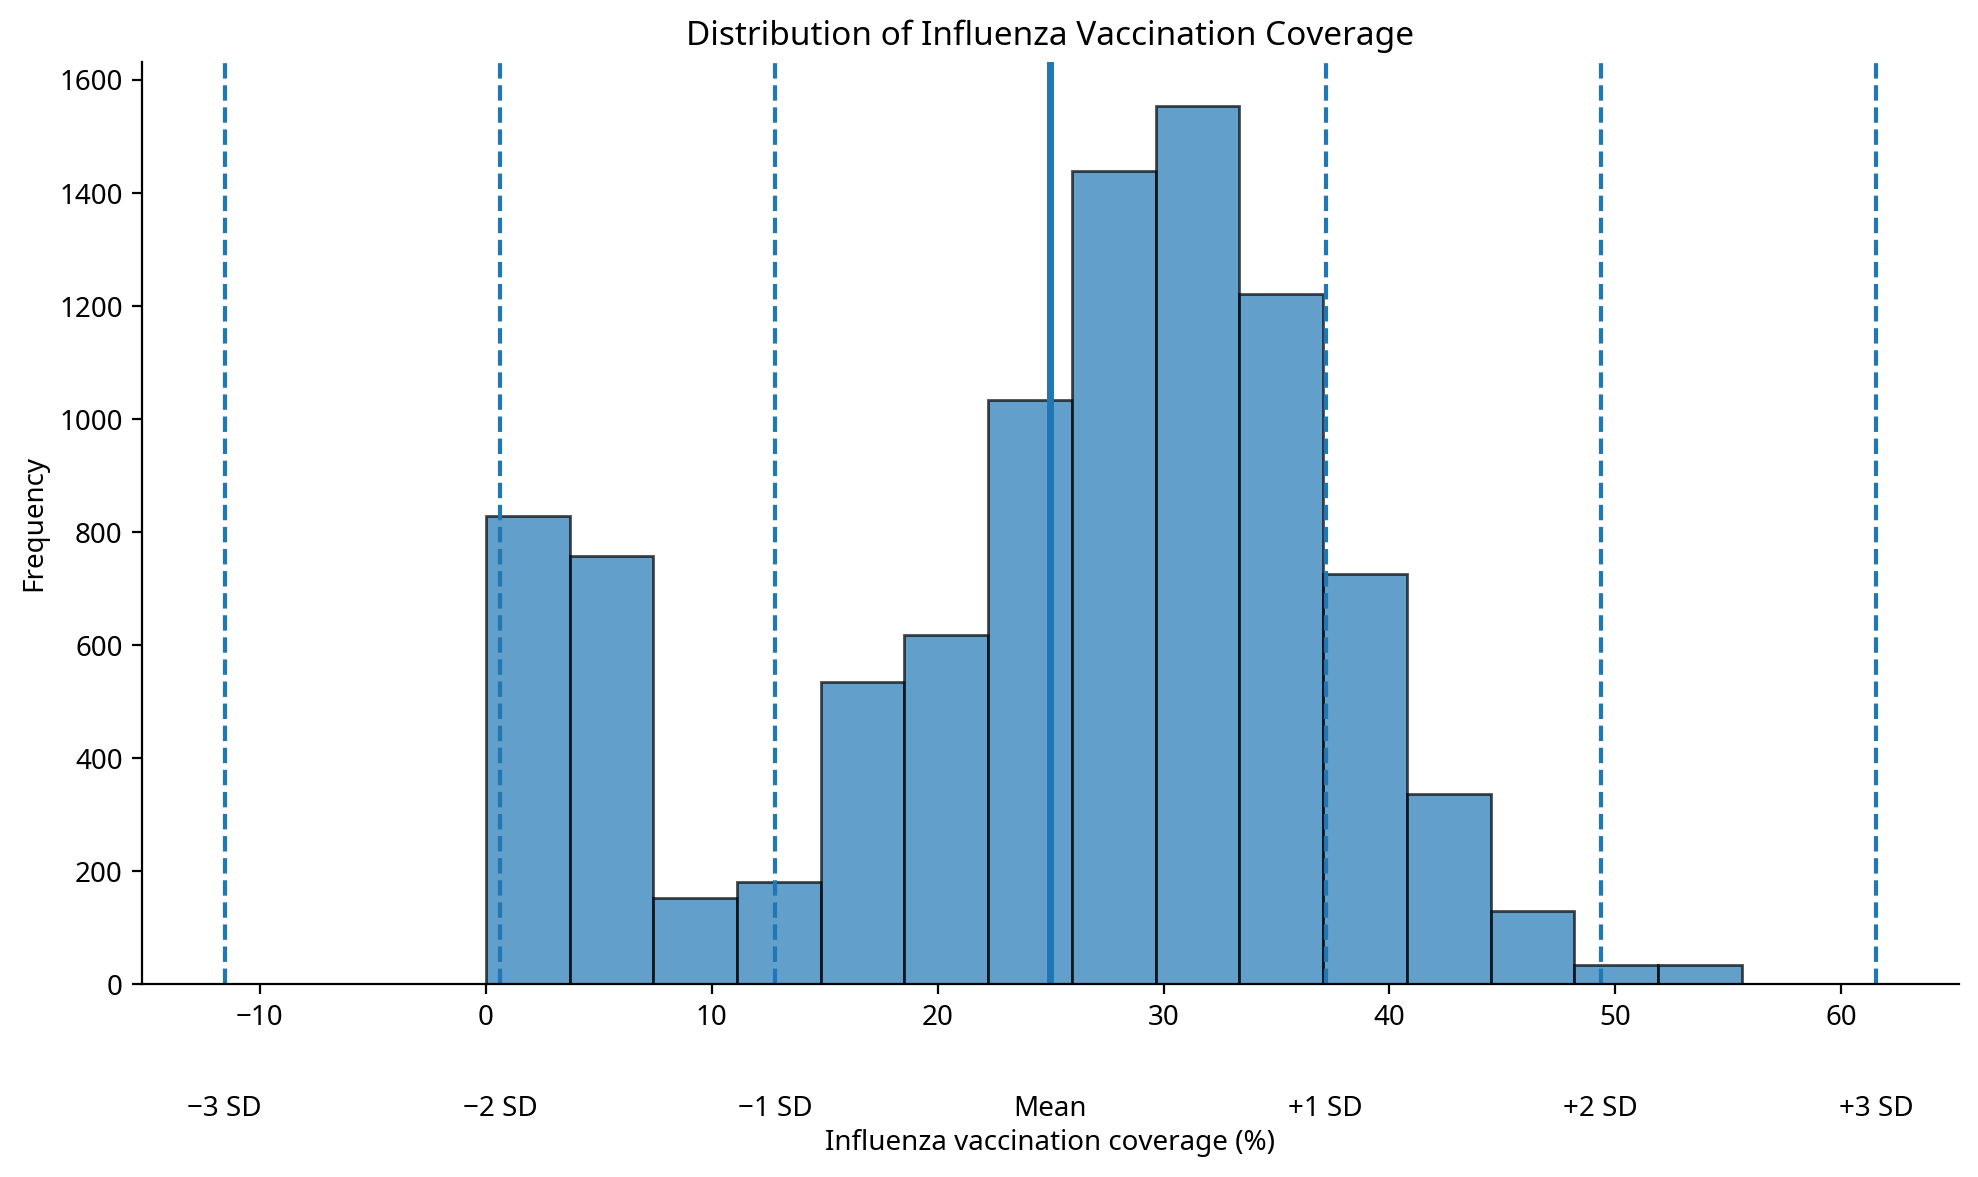

In [27]:
flu_vax["Estimate (%)"] = pd.to_numeric(
    flu_vax["Estimate (%)"],
    errors="coerce"
)

flu_vax = flu_vax.dropna(subset=["Estimate (%)"])

college_age = flu_vax[
    flu_vax["Dimension Type"].str.contains("Age", case=False, na=False)
    & flu_vax["Dimension"].eq("18-49 Years")
].copy()

college_age = college_age.dropna(subset=["Estimate (%)"])

import numpy as np
import matplotlib.pyplot as plt

x = college_age["Estimate (%)"]
mean = x.mean()
std  = x.std()

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
ax.hist(
    x,
    bins=15,
    edgecolor="black",
    alpha=0.7
)

# Mean
ax.axvline(mean, linewidth=2.5)

# Standard deviations
for k in [1, 2, 3]:
    ax.axvline(mean - k*std, linestyle="--", linewidth=1.5)
    ax.axvline(mean + k*std, linestyle="--", linewidth=1.5)

# Labels underneath the x-axis
positions = [
    mean - 3*std,
    mean - 2*std,
    mean - 1*std,
    mean,
    mean + 1*std,
    mean + 2*std,
    mean + 3*std
]

labels = [
    "−3 SD",
    "−2 SD",
    "−1 SD",
    "Mean",
    "+1 SD",
    "+2 SD",
    "+3 SD"
]

for pos, label in zip(positions, labels):
    ax.text(
        pos, -0.12,
        label,
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontsize=10
    )

ax.set_xlabel("Influenza vaccination coverage (%)", labelpad=35)
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Influenza Vaccination Coverage")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

We see that the mean influenza vaccine coverage in the US for those aged 18-49 is 25%. Then, whats the measurement scale? where should we draw the ticks on our ruler? One idea is to use every std (or say a 1/2 standard deviation). They are natural to the collected observations and have an interpretastion for alot (2 standard deviations) or a little (0.01 standard deviations). Note the standard deviation for the vaccine coverage is 12%.  